In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/home/lolkek3310/python/Подготовка Гомель/CC GENERAL/CC GENERAL.csv')

print(df)

print(df.info())

     CUST_ID      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0     C10001    40.900749           0.818182      95.40              0.00   
1     C10002  3202.467416           0.909091       0.00              0.00   
2     C10003  2495.148862           1.000000     773.17            773.17   
3     C10004  1666.670542           0.636364    1499.00           1499.00   
4     C10005   817.714335           1.000000      16.00             16.00   
...      ...          ...                ...        ...               ...   
8945  C19186    28.493517           1.000000     291.12              0.00   
8946  C19187    19.183215           1.000000     300.00              0.00   
8947  C19188    23.398673           0.833333     144.40              0.00   
8948  C19189    13.457564           0.833333       0.00              0.00   
8949  C19190   372.708075           0.666667    1093.25           1093.25   

      INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0       

In [83]:
print(df.isnull().sum())

df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())

df.drop('CUST_ID', axis=1, inplace=True)

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


Маштабирование:


In [84]:
from sklearn.preprocessing import StandardScaler

# Создаем объект масштабировщика
scaler = StandardScaler()

# Обучаем его на наших данных и сразу трансформируем их
# Мы получаем массив чисел, где все признаки "равноправны"
scaler.fit(df)
df_scaled = scaler.transform(df)
# Посмотрим, как теперь выглядят данные (первая строка)
print(df_scaled[0])

[-0.73198937 -0.24943448 -0.42489974 -0.35693402 -0.34907882 -0.46678555
 -0.80649035 -0.67866081 -0.70731317 -0.67534886 -0.47606982 -0.51133325
 -0.9603784  -0.52897879 -0.3024     -0.52555097  0.36067954]


PCA:


In [85]:
from sklearn.decomposition import PCA

# Мы хотим сжать 17 признаков всего в 2, чтобы построить график
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Теперь у нас вместо 17 колонок — всего две: PCA1 и PCA2
print(df_pca.shape) # Выведет (8950, 2)

(8950, 2)


Локоть


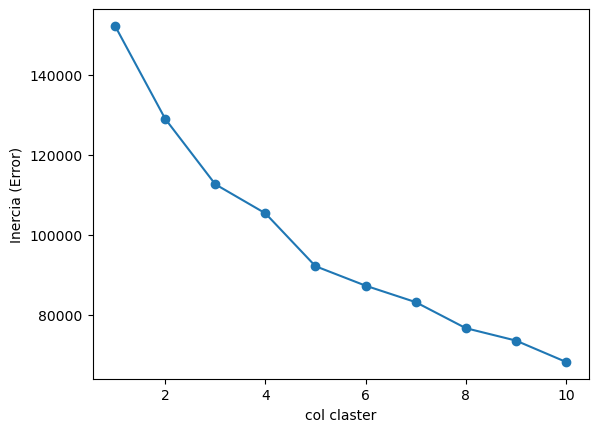

In [86]:
from sklearn.cluster import KMeans

inetria = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df_scaled)
    inetria.append(kmeans.inertia_)

plt.plot(range(1, 11), inetria, marker = 'o' )
plt.xlabel('col claster')
plt.ylabel('Inercia (Error)')
plt.show()

In [87]:
kmeans = KMeans(n_clusters=4, random_state=42)

clusters = kmeans.fit_predict(df_scaled)

df['Cluster'] = clusters

interpretation = df.groupby('Cluster').mean()

print(df[['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'Cluster']].head())

       BALANCE  PURCHASES  CASH_ADVANCE  Cluster
0    40.900749      95.40      0.000000        3
1  3202.467416       0.00   6442.945483        0
2  2495.148862     773.17      0.000000        2
3  1666.670542    1499.00    205.788017        3
4   817.714335      16.00      0.000000        3


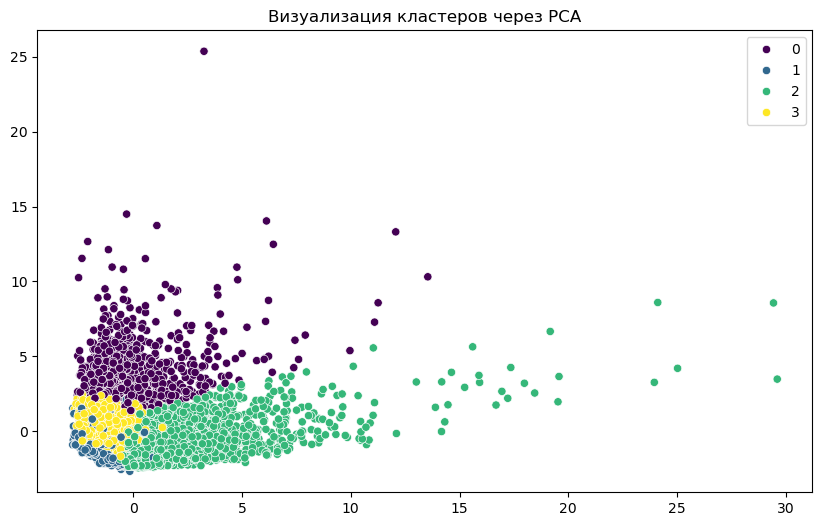

In [88]:
# Используем df_pca (2 колонки), который мы сделали раньше
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_pca[:, 0], y=df_pca[:, 1], hue=clusters, palette='viridis')
plt.title('Визуализация кластеров через PCA')
plt.show()

In [89]:
best_cols = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS']

cluster_analysis = df.groupby('Cluster')[best_cols].mean()

cluster_analysis['COUNT'] = df.groupby('Cluster')['BALANCE'].count()

print(cluster_analysis)

             BALANCE    PURCHASES  CASH_ADVANCE  CREDIT_LIMIT     PAYMENTS  \
Cluster                                                                      
0        5010.394668   716.017789   5065.974690   8208.653578  4173.817878   
1         108.430006   350.247868    299.482324   3632.112008  1036.853064   
2        1253.817942  2182.022178    234.564524   5121.987288  2148.583305   
3        1495.324927   283.482824    782.285268   3216.349960   947.961448   

         COUNT  
Cluster         
0          977  
1         1487  
2         3118  
3         3368  


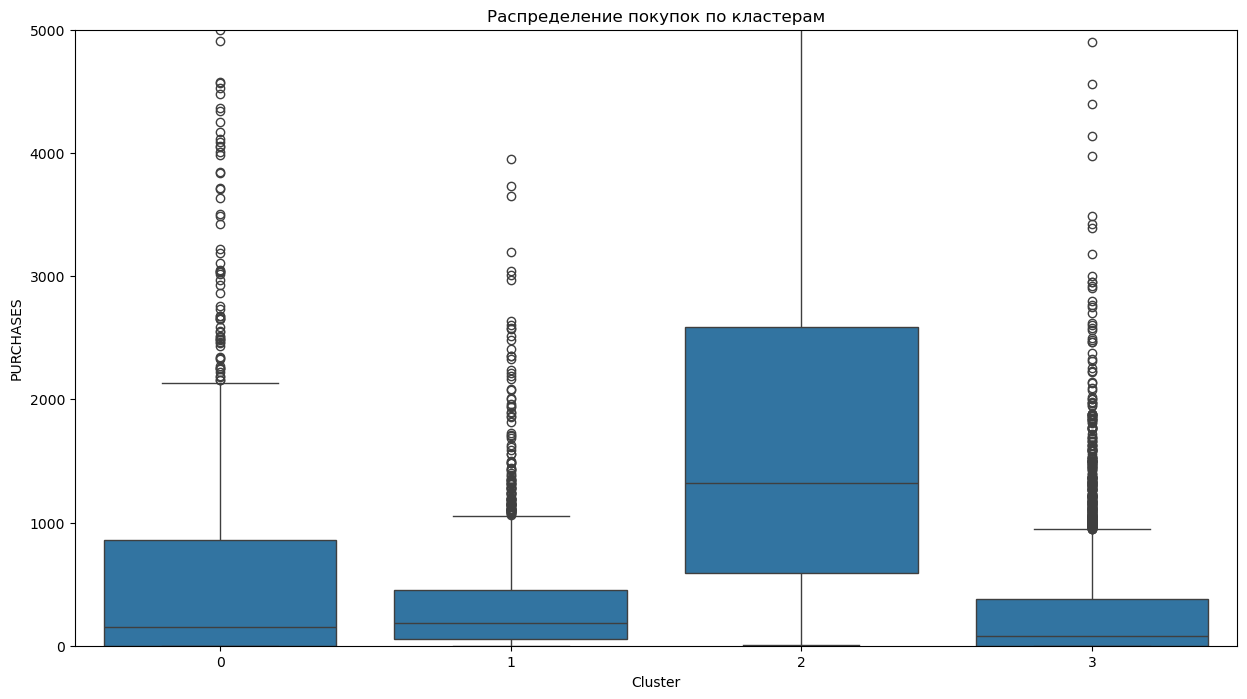

In [90]:
plt.figure(figsize=(15, 8))
# Рисуем график для колонки 'PURCHASES' по кластерам
sns.boxplot(x='Cluster', y='PURCHASES', data=df)
plt.title('Распределение покупок по кластерам')
plt.ylim(0, 5000) # Ограничим график для наглядности (уберем супер-выбросы)
plt.show()

/tmp/ipykernel_13107/1753924876.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df, palette='viridis')
/tmp/ipykernel_13107/1753924876.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df, palette='viridis')
/tmp/ipykernel_13107/1753924876.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df, palette='viridis')
/tmp/ipykernel_13107/1753924876.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assi

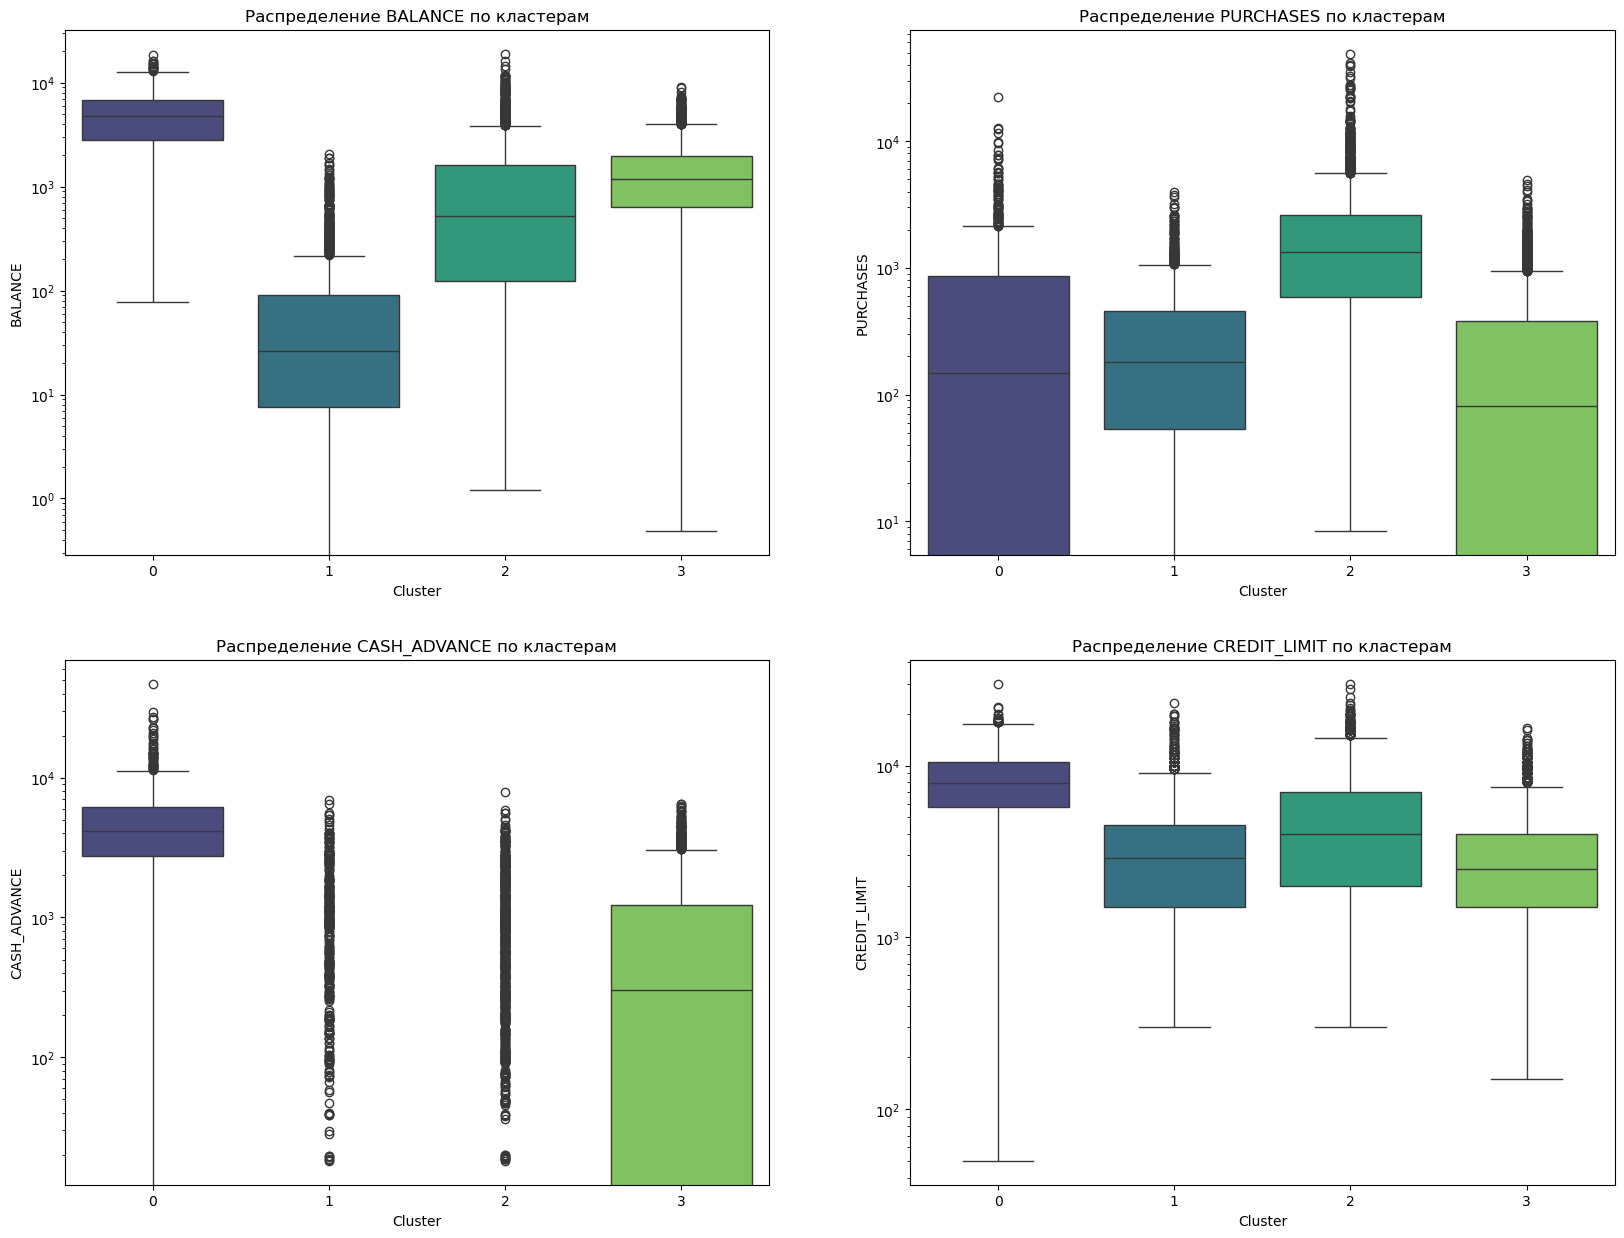

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt

# Список колонок, которые мы хотим сравнить
features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT']

# Создаем сетку из графиков (2 строки по 2 графика)
plt.figure(figsize=(20, 15))

for i, col in enumerate(features):
    plt.subplot(2, 2, i + 1) # Создаем "под-график" в сетке
    sns.boxplot(x='Cluster', y=col, data=df, palette='viridis')
    plt.title(f'Распределение {col} по кластерам')
    # Ограничим верхнюю границу, чтобы выбросы не "сжимали" график
    plt.yscale('log') # Используем логарифмическую шкалу, если разброс огромный

plt.show()

In [92]:
# Сохраняем таблицу с клиентами и их номерами кластеров в новый CSV файл
df.to_csv('/home/lolkek3310/python/Подготовка Гомель/CC GENERAL/segmented_customers.csv', index=False)

print("Файл успешно сохранен! Теперь у каждого клиента есть своя метка.")

Файл успешно сохранен! Теперь у каждого клиента есть своя метка.
